In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Dataset

In [2]:
df = pd.read_csv("../Dataset/S2_chest_data.csv")
df.head(2)

,ACC_X,ACC_Y,ACC_Z,ECG,EMG,EDA,Temp,Resp,Label
0,0.9554,-0.2220,-0.5580,0.021423,-0.004440,5.250549,30.120758,-1.148987,0
1,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,0


### Check whether the dataset is balanced or not

In [4]:
df["Label"].unique()

array([0, 1, 2, 6, 4, 3, 7])

**According the dataset Doc**

| Label       | Meaning                           |
| ----------- | --------------------------------- |
| **0**       | Undefined / transient state       |
| **1**       | Baseline (relaxed, resting state) |
| **2**       | Stress condition                  |
| **3**       | Amusement (watching funny videos) |
| **4**       | Meditation                        |
| **5, 6, 7** | Not used / should be ignored      |

Label = 0 means: The subject is not clearly in baseline, stress, amusement, or meditation and can be removed.

In [11]:
# Actual available data
accept_label = [1, 2, 3, 4]
df = df[df["Label"].isin(accept_label)]
df.shape

(2022299, 9)

In [12]:
df["Label"].value_counts()

Label
1    800800
4    537599
2    430500
3    253400
Name: count, dtype: int64

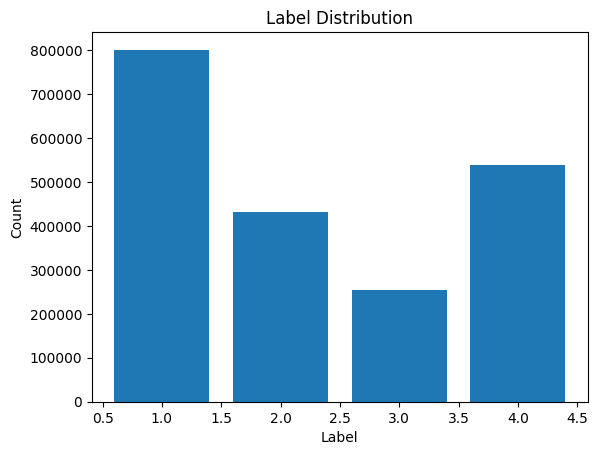

In [13]:
counts = df["Label"].value_counts()

x = counts.index
y = counts.values

plt.bar(x, y)

plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Label Distribution")

plt.show()

### Result:

Dataset is imbalanced

### Check for null values

In [14]:
df.isnull().sum()

ACC_X    0
ACC_Y    0
ACC_Z    0
ECG      0
EMG      0
EDA      0
Temp     0
Resp     0
Label    0
dtype: int64

### Result:
no null value present

### Check for outliers

In [15]:
df.describe()

,ACC_X,ACC_Y,ACC_Z,ECG,EMG,EDA,Temp,Resp,Label
count,2.022299e+06,2.022299e+06,2.022299e+06,2.022299e+06,2.022299e+06,2.022299e+06,2.022299e+06,2.022299e+06,2.022299e+06
mean,6.905893e-01,-1.254201e-01,-5.541978e-01,1.189813e-03,-2.410597e-03,1.477928e+00,3.056060e+01,5.047145e-02,2.260989e+00
std,1.585121e-01,5.674518e-02,2.676459e-01,1.364764e-01,9.685848e-03,9.621079e-01,1.592403e+00,2.229207e+00,1.231469e+00
min,3.116000e-01,-4.194000e-01,-1.004000e+00,-1.499405e+00,-2.458191e-01,2.632141e-01,2.804526e+01,-2.019653e+01,1.000000e+00
25%,6.046000e-01,-1.446000e-01,-7.346000e-01,-6.037903e-02,-7.553101e-03,7.904053e-01,2.856464e+01,-1.321411e+00,1.000000e+00
50%,6.286000e-01,-1.240000e-01,-7.094000e-01,1.199341e-02,-1.556396e-03,1.216888e+00,3.127814e+01,-1.724243e-01,2.000000e+00
75%,8.760000e-01,-7.340002e-02,-2.814000e-01,4.618835e-02,3.295898e-03,1.777267e+00,3.193958e+01,1.438904e+00,4.000000e+00
max,1.380600e+00,2.024000e-01,1.041800e+00,1.415726e+00,1.978912e-01,5.756760e+00,3.437039e+01,1.927032e+01,4.000000e+00


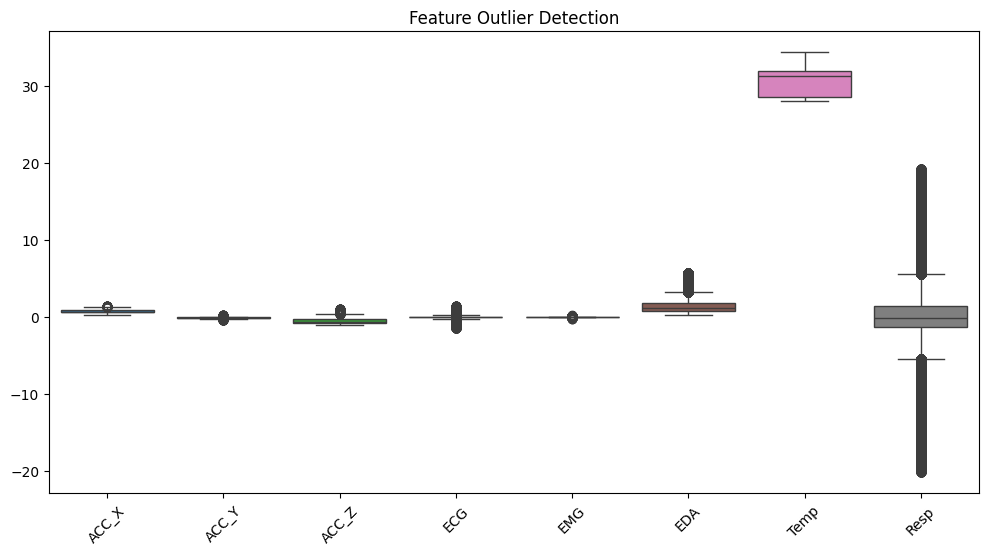

In [17]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df.drop(columns=["Label"]))

plt.xticks(rotation=45)
plt.title("Feature Outlier Detection")

plt.show()

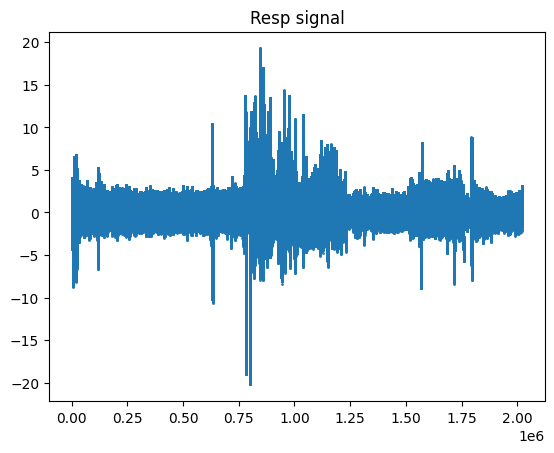

In [18]:
plt.scatter(range(len(df)), df["Resp"], s=1)
plt.title("Resp signal")
plt.show()

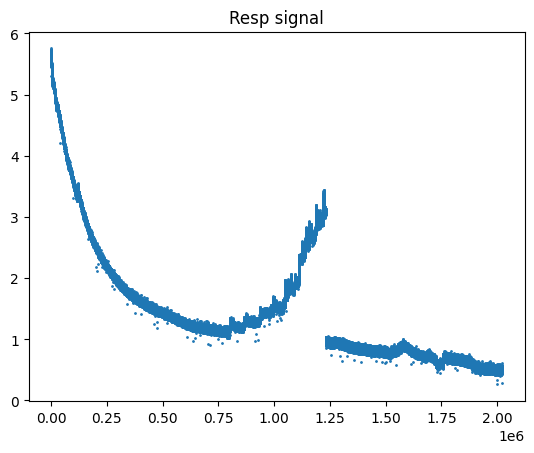

In [19]:
plt.scatter(range(len(df)), df["EDA"], s=1)
plt.title("Resp signal")
plt.show()

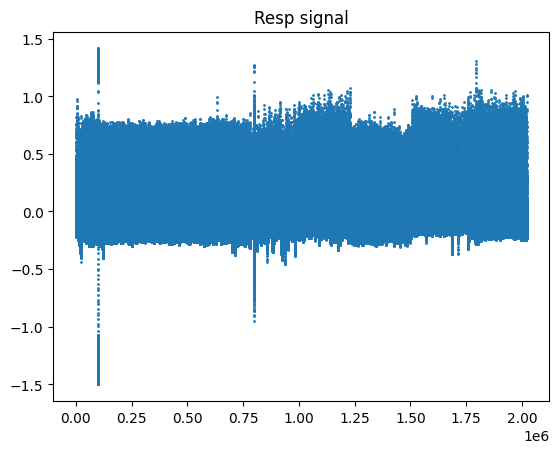

In [20]:
plt.scatter(range(len(df)), df["ECG"], s=1)
plt.title("Resp signal")
plt.show()

### Result:
There exist the outlier mainly in `Resp` `EDA` and `ECG` column